# Лабораторна робота: Регресійний аналіз 

У цій роботі ми ознайомимося з методами регресійного аналізу, навчимося працювати з реальними і штучно створеними наборами даних для регресійного аналізу, застосовувати моделі для прогнозування даних та аналізувати результати.

In [2]:
%pip install seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

sns.set(style="whitegrid")
print("Бібліотеки успішно імпортовано!")

Бібліотеки успішно імпортовано!


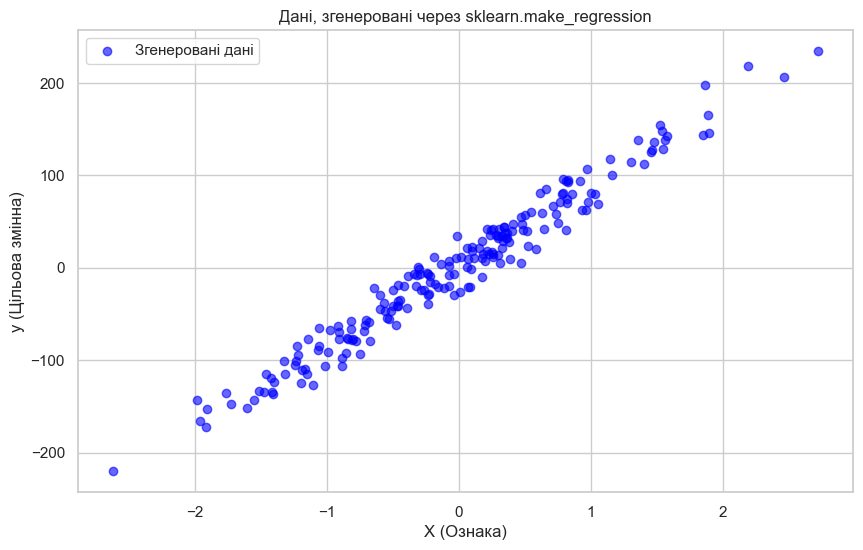

R2 Score (точність): 0.9681
MSE (похибка): 246.1218


In [4]:
# n_samples=200 - кількість точок
# n_features=1 - кількість ознак (X)
# noise=15 - розкид даних (шум)
X_gen, y_gen = make_regression(n_samples=200, n_features=1, noise=15, random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(X_gen, y_gen, color='blue', alpha=0.6, label='Згенеровані дані')
plt.title("Дані, згенеровані через sklearn.make_regression")
plt.xlabel("X (Ознака)")
plt.ylabel("y (Цільова змінна)")
plt.legend()
plt.show()

X_train, X_test, y_train, y_test = train_test_split(X_gen, y_gen, test_size=0.2, random_state=42)

model_gen = LinearRegression()
model_gen.fit(X_train, y_train)
y_pred_gen = model_gen.predict(X_test)

print(f"R2 Score (точність): {r2_score(y_test, y_pred_gen):.4f}")
print(f"MSE (похибка): {mean_squared_error(y_test, y_pred_gen):.4f}")

Перші 5 рядків датасету:


,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


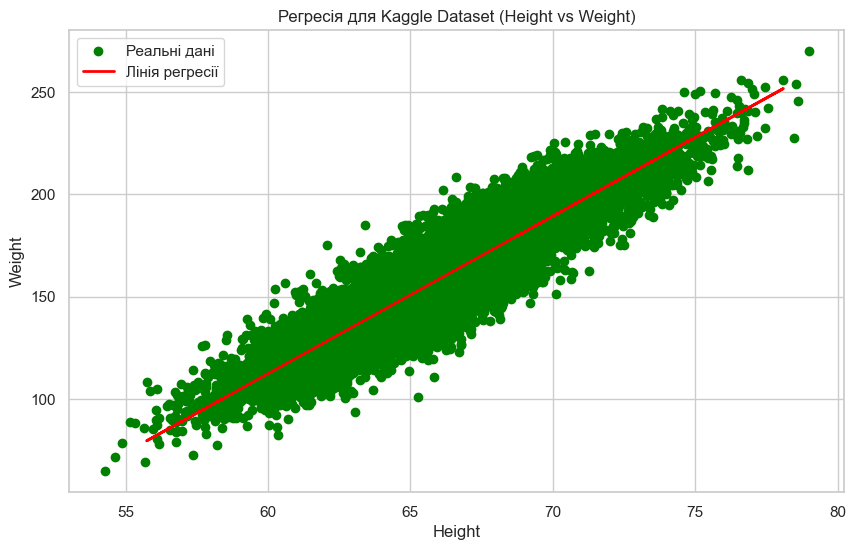

Kaggle Model R2 Score: 0.8577


In [5]:
file_path = 'weight-height.csv' 

try:
    df = pd.read_csv(file_path)
    print("Перші 5 рядків датасету:")
    display(df.head())

    target_col = 'Weight' 
    feature_col = 'Height' 

    X_kaggle = df[[feature_col]].values
    y_kaggle = df[target_col].values

    X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(X_kaggle, y_kaggle, test_size=0.2, random_state=42)
    
    model_kaggle = LinearRegression()
    model_kaggle.fit(X_train_k, y_train_k)
    y_pred_k = model_kaggle.predict(X_test_k)

    plt.figure(figsize=(10, 6))
    plt.scatter(X_kaggle, y_kaggle, color='green', label='Реальні дані')
    plt.plot(X_test_k, y_pred_k, color='red', linewidth=2, label='Лінія регресії')
    plt.title(f"Регресія для Kaggle Dataset ({feature_col} vs {target_col})")
    plt.xlabel(feature_col)
    plt.ylabel(target_col)
    plt.legend()
    plt.show()

    print(f"Kaggle Model R2 Score: {r2_score(y_test_k, y_pred_k):.4f}")

except FileNotFoundError:
    print(f"Файл {file_path} не знайдено. Будь ласка, завантажте файл з Kaggle та перевірте його назву.")
except KeyError:
    print("Помилка в назвах колонок. Перевірте, чи правильно ви вказали feature_col та target_col.")

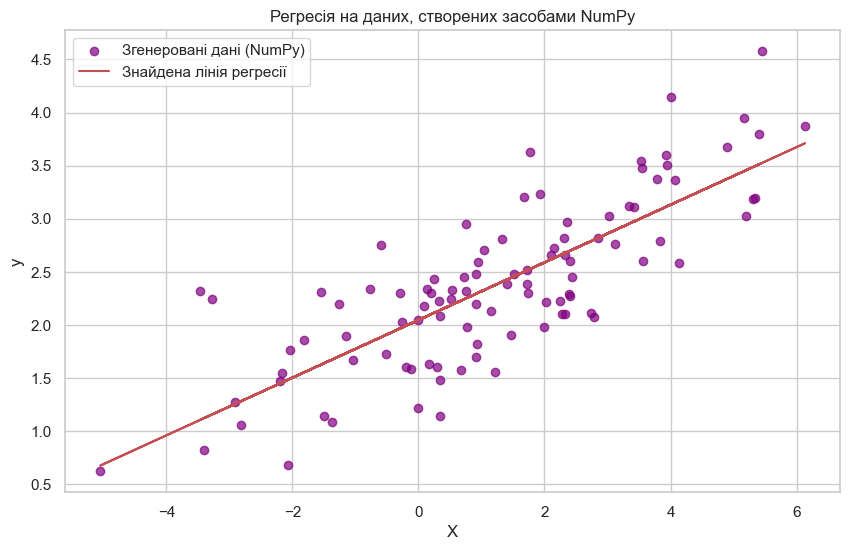

Справжній перетин (b): 2, Знайдений моделлю: 2.05
Справжній нахил (m): 0.3, Знайдений моделлю: 0.27


In [6]:
np.random.seed(42)

n_samples = 100
X_custom = 2.5 * np.random.randn(n_samples) + 1.5  
res = 0.5 * np.random.randn(n_samples)      

y_custom = 2 + 0.3 * X_custom + res

X_custom_reshaped = X_custom.reshape(-1, 1)

model_custom = LinearRegression()
model_custom.fit(X_custom_reshaped, y_custom)
y_pred_custom = model_custom.predict(X_custom_reshaped)

plt.figure(figsize=(10, 6))
plt.scatter(X_custom, y_custom, label='Згенеровані дані (NumPy)', color='purple', alpha=0.7)
plt.plot(X_custom, y_pred_custom, 'r', label='Знайдена лінія регресії')
plt.title("Регресія на даних, створених засобами NumPy")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

print(f"Справжній перетин (b): 2, Знайдений моделлю: {model_custom.intercept_:.2f}")
print(f"Справжній нахил (m): 0.3, Знайдений моделлю: {model_custom.coef_[0]:.2f}")